In [1]:
!pip install torch torchvision
!pip install git+https://github.com/cvg/LightGlue.git
!pip install opencv-python-headless numpy matplotlib ipywidgets scikit-learn scipy scikit-image

  Cloning https://github.com/cvg/LightGlue.git to /tmp/pip-req-build-zphgybxe
  Running command git clone --filter=blob:none --quiet https://github.com/cvg/LightGlue.git /tmp/pip-req-build-zphgybxe
  Resolved https://github.com/cvg/LightGlue.git to commit eb42fee2d71449efb0aa5c10549752b5d75384d8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 67.6 MB/s eta 0:00:00
  Created wheel for lightglue: filename=lightglue-0.0-py3-none-any.whl size=40244 sha256=772c94a2af3347c2b5b9c3dda6db7a5ba41e4b5a3d850841eaadefd21aa790f9
  Stored in directory: /tmp/pip-ephem-wheel-cache-ehm_hwr6/wheels/dc/16/88/ad4ddb490c3a6ff37eeface44b776cb588b19e169210e0fbf1
Successfully built lightglue
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.8 MB/s eta 0:00:00


In [2]:
!pip install imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 64.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Imports & Configuration

In [2]:
import numpy as np
import cv2
import glob
import os
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider

import torch
from scipy.optimize import least_squares
from scipy.sparse import lil_matrix

# LightGlue repo ships both SuperPoint and the matcher
from lightglue import LightGlue, SuperPoint
from lightglue.utils import load_image, rbd  # rbd = remove batch dim
IMAGE_DIR   = "/content/drive/MyDrive/thermal_images"   # .tiff files
PARAMS_FILE = "/content/drive/MyDrive/thermal_images/camera_params.npz"

VOXEL_GRID_SIZE  = 96
VOXEL_EXTENT_XY  = 0.23
VOXEL_EXTENT_Z   = 0.30
VOXEL_Z_OFFSET   = 0.00

SP_MAX_KEYPOINTS = 2048
SP_NMS_RADIUS    = 4
MATCH_THRESHOLD  = 0.1

RANSAC_CONF       = 0.999
RANSAC_THRESH_PX  = 1.0

KNOWN_TURNTABLE_RADIUS_M = None   # e.g. 0.15
KNOWN_BASELINE_M         = None   # e.g. 0.05

BA_MAX_ITER        = 200          # scipy least_squares max iterations
BA_LOSS            = "huber"      # robust kernel: 'linear', 'soft_l1', 'huber', 'cauchy'
BA_FTOL            = 1e-6
BA_MIN_TRACK_LEN   = 3            # minimum views a 3-D point must appear in
BA_REPROJ_THRESH   = 4.0          # pixels — points above this after BA are culled
BA_CONF_WEIGHTING  = True         # weight residuals by SuperPoint keypoint confidence

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print("Config OK")

Device: cuda
Config OK


In [3]:
cam  = np.load(PARAMS_FILE)
K    = cam["K"].astype(np.float64)
dist = cam["dist"].astype(np.float64)
print("K:\n", K)
print("dist:", dist)

image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.tiff")))
if not image_paths:
    image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.tif")))
assert len(image_paths) > 0, f"No .tiff files found in {IMAGE_DIR}"
num_views = len(image_paths)
print(f"Found {num_views} images")
print("First image:", image_paths[0])

K:
 [[102.91792913   0.          87.27122227]
 [  0.         102.42992317  51.08259919]
 [  0.           0.           1.        ]]
dist: [[-0.34987549  0.14901673  0.000854   -0.00384354 -0.04705683]]
Found 32 images
First image: /content/drive/MyDrive/thermal_images/cap_00.tiff


In [4]:
def load_cv(path):
    """Load + undistort + optionally preprocess a TIFF image (returns BGR uint8)."""
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    assert img is not None, f"Could not read {path}"
    img = cv2.undistort(img, K, dist)
    return img


In [5]:
extractor = SuperPoint(
    max_num_keypoints=SP_MAX_KEYPOINTS,
    nms_radius=SP_NMS_RADIUS,
).eval().to(DEVICE)


def extract_superpoint(path):
    """
    Returns a dict with keys:
      keypoints        : (N, 2)   float32 pixel coords
      descriptors      : (N, 256) float32
      keypoint_scores  : (N,)     float32
    All tensors are on CPU.
    """
    img_bgr = load_cv(path)           # preprocessed BGR uint8
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = (torch.from_numpy(img_rgb).float().permute(2, 0, 1) / 255.0).to(DEVICE)

    with torch.no_grad():
        feats = extractor.extract(img_tensor.unsqueeze(0))
    return {k: v[0].cpu() for k, v in feats.items()}


print("Extracting SuperPoint features from all frames…")
all_feats = []
for i, path in enumerate(image_paths):
    f = extract_superpoint(path)
    all_feats.append(f)
    if (i + 1) % max(1, num_views // 8) == 0 or i == num_views - 1:
        print(f"  {i+1:3d}/{num_views}  kpts: {f['keypoints'].shape[0]}")

print("Extraction done.")

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_v1.pth" to /root/.cache/torch/hub/checkpoints/superpoint_v1.pth


100%|██████████| 4.96M/4.96M [00:00<00:00, 102MB/s]


Extracting SuperPoint features from all frames…
    4/32  kpts: 315
    8/32  kpts: 226
   12/32  kpts: 335
   16/32  kpts: 343
   20/32  kpts: 299
   24/32  kpts: 276
   28/32  kpts: 293
   32/32  kpts: 371
Extraction done.


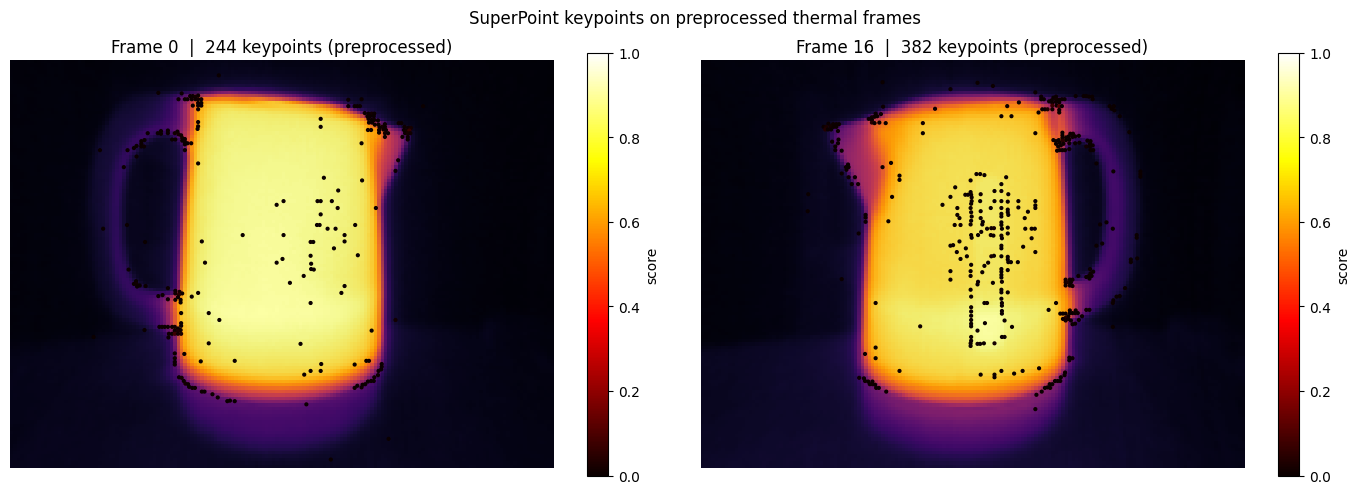

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx in zip(axes, [0, num_views // 2]):
    img = load_cv(image_paths[idx])
    kpts   = all_feats[idx]["keypoints"].numpy()
    scores = all_feats[idx]["keypoint_scores"].numpy()
    sc = ax.scatter(kpts[:, 0], kpts[:, 1],
                    c=scores, cmap="hot", s=4, vmin=0, vmax=1)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {idx}  |  {len(kpts)} keypoints (preprocessed)")
    ax.axis("off")
    plt.colorbar(sc, ax=ax, label="score")
plt.suptitle("SuperPoint keypoints on preprocessed thermal frames")
plt.tight_layout()
plt.show()

In [7]:
matcher = LightGlue(
    features="superpoint",
    depth_confidence=0.95,
    width_confidence=0.99,
    filter_threshold=MATCH_THRESHOLD,
).eval().to(DEVICE)


def match_pair(feats0, feats1):
    """
    Run LightGlue on two SuperPoint feature dicts.
    Returns:
        pts0, pts1 : (M, 2) float32 matched pixel coords
        scores     : (M,)   float32 match confidence
        idx0, idx1 : (M,)   int     indices into original keypoint arrays
    """
    f0 = {k: v.unsqueeze(0).to(DEVICE) for k, v in feats0.items()}
    f1 = {k: v.unsqueeze(0).to(DEVICE) for k, v in feats1.items()}

    with torch.no_grad():
        result = matcher({"image0": f0, "image1": f1})

    result   = {k: v.cpu() if isinstance(v, torch.Tensor) else v for k, v in rbd(result).items()}
    matches  = result["matches"]
    m_scores = result["matching_scores0"]

    valid  = matches[:, 0] >= 0
    idx0   = matches[valid, 0]
    idx1   = matches[valid, 1]
    pts0   = feats0["keypoints"][idx0].numpy()
    pts1   = feats1["keypoints"][idx1].numpy()
    scores = m_scores[idx0].numpy()
    return pts0, pts1, scores, idx0.numpy(), idx1.numpy()


print("Matching consecutive pairs…")
all_matches = {}
pairs = [(i, (i + 1) % num_views) for i in range(num_views)]

for i, j in pairs:
    pts0, pts1, scores, idx0, idx1 = match_pair(all_feats[i], all_feats[j])
    all_matches[(i, j)] = (pts0, pts1, scores, idx0, idx1)
    if (i + 1) % max(1, num_views // 8) == 0 or i == num_views - 1:
        print(f"  {i:2d}->{j:2d}  {len(pts0)} matches  (mean conf {scores.mean():.3f})")

print("Matching done.")

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/superpoint_lightglue.pth" to /root/.cache/torch/hub/checkpoints/superpoint_lightglue_v0-1_arxiv.pth


100%|██████████| 45.3M/45.3M [00:00<00:00, 181MB/s]


Matching consecutive pairs…
   3-> 4  89 matches  (mean conf 0.371)
   7-> 8  52 matches  (mean conf 0.318)
  11->12  109 matches  (mean conf 0.326)
  15->16  121 matches  (mean conf 0.353)
  19->20  77 matches  (mean conf 0.365)
  23->24  130 matches  (mean conf 0.460)
  27->28  99 matches  (mean conf 0.518)
  31-> 0  68 matches  (mean conf 0.213)
Matching done.


48


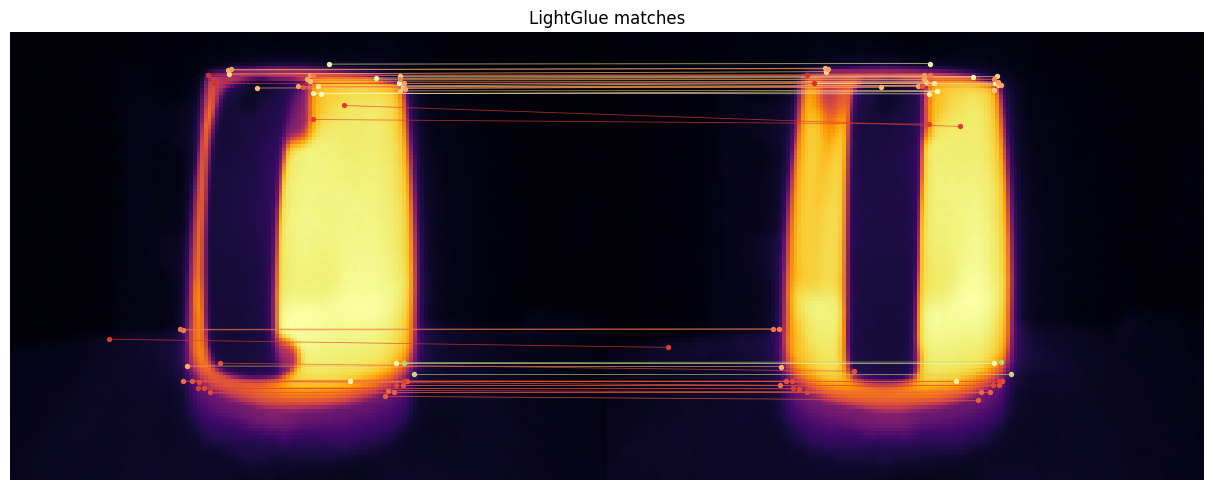

In [8]:
MATCH_VIS_IDX = 6
i, j = MATCH_VIS_IDX, (MATCH_VIS_IDX + 1) % num_views
pts0, pts1, scores, idx0, idx1 = match_pair(all_feats[i], all_feats[j])
print(len(scores))
#pts0, pts1, scores = all_matches[(i, j)][:3]

img0 = load_cv(image_paths[i])
img1 = load_cv(image_paths[j])
canvas = np.concatenate([img0, img1], axis=1)
W = img0.shape[1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
top = np.argsort(scores)[::-1][:100]
cmap = plt.cm.RdYlGn
for k in top:
    x0, y0 = pts0[k]; x1, y1 = pts1[k]
    color = cmap(scores[k])
    ax.plot([x0, x1 + W], [y0, y1], "-", color=color, linewidth=0.6, alpha=0.7)
    ax.scatter([x0, x1 + W], [y0, y1], s=8, color=color, zorder=5)
#ax.set_title(f"Frames {i} → {j}: {len(pts0)} LightGlue matches")
ax.set_title(f"LightGlue matches")
ax.axis("off"); plt.tight_layout(); plt.show()

In [9]:
def recover_relative_pose(pts0, pts1, K,
                           ransac_thresh=RANSAC_THRESH_PX, conf=RANSAC_CONF):
    """RANSAC essential matrix + chirality check."""
    E, mask = cv2.findEssentialMat(
        pts0.astype(np.float64), pts1.astype(np.float64), K,
        method=cv2.RANSAC, prob=conf, threshold=ransac_thresh)
    inliers = (mask.ravel() == 1)
    _, R, t, _ = cv2.recoverPose(
        E,
        pts0[inliers].astype(np.float64),
        pts1[inliers].astype(np.float64),
        K)
    return R, t, inliers   # t is unit-norm


def compute_scale_factor(R_world_to_cam, t_world_to_cam, num_views):
    """
    Determine the metric scale factor for all translations.

    Priority:
      1. KNOWN_TURNTABLE_RADIUS_M  — uses average chord between consecutive
         camera centres (C = -R^T t) and the turntable radius to find scale.
      2. KNOWN_BASELINE_M          — target mean |t_rel| per step.
      3. Fallback: 1.0 (no scaling).
    """
    if KNOWN_TURNTABLE_RADIUS_M is not None:
        r = KNOWN_TURNTABLE_RADIUS_M
        # Camera centres in world frame (unit scale)
        centres_unit = np.array(
            [-R_world_to_cam[i].T @ t_world_to_cam[i].ravel()
             for i in range(num_views)])
        # Mean chord length between consecutive centres
        chords = np.linalg.norm(np.diff(centres_unit, axis=0), axis=1)
        mean_chord = chords.mean()
        # For N equally-spaced positions on a circle of radius r:
        # chord ≈ 2r sin(π/N).  We invert this:
        N = num_views
        expected_chord = 2 * r * np.sin(np.pi / N)
        scale = expected_chord / (mean_chord + 1e-12)
        print(f"Scale from turntable radius: unit chord={mean_chord:.4f}, "
              f"expected={expected_chord:.4f}, scale={scale:.4f}")
        return scale

    elif KNOWN_BASELINE_M is not None:
        # Mean relative translation (should be ~1.0 from recoverPose)
        t_mags = []
        for i in range(num_views - 1):
            R_prev = R_world_to_cam[i]; t_prev = t_world_to_cam[i]
            R_curr = R_world_to_cam[i+1]; t_curr = t_world_to_cam[i+1]
            # t_rel in camera-i frame
            t_rel = t_curr - R_curr @ R_prev.T @ t_prev
            t_mags.append(np.linalg.norm(t_rel))
        mean_t = np.mean(t_mags)
        scale  = KNOWN_BASELINE_M / (mean_t + 1e-12)
        print(f"Scale from known baseline: mean |t_rel|={mean_t:.4f}, "
              f"target={KNOWN_BASELINE_M}, scale={scale:.4f}")
        return scale

    else:
        print("No physical scale constraint provided — scale=1.0 (unit translation).")
        return 1.0


print("Estimating poses from Essential matrices…")
R_world_to_cam = [np.eye(3)]
t_world_to_cam = [np.zeros((3, 1))]
inlier_counts  = []

for i in range(num_views - 1):
    j = i + 1
    pts0, pts1, scores = all_matches[(i, j)][:3]

    if len(pts0) < 8:
        print(f"  WARNING: <8 matches for {i}->{j}, duplicating pose.")
        R_world_to_cam.append(R_world_to_cam[-1].copy())
        t_world_to_cam.append(t_world_to_cam[-1].copy())
        inlier_counts.append(0)
        continue

    R_rel, t_rel, inliers = recover_relative_pose(pts0, pts1, K)
    R_prev = R_world_to_cam[-1]; t_prev = t_world_to_cam[-1]
    R_new  = R_rel @ R_prev
    t_new  = R_rel @ t_prev + t_rel  # unit-scale accumulation

    R_world_to_cam.append(R_new)
    t_world_to_cam.append(t_new)
    inlier_counts.append(inliers.sum())

    angle_deg = np.degrees(np.arccos(np.clip((np.trace(R_rel) - 1) / 2, -1, 1)))
    print(f"  Frame {i:2d}->{j:2d}  inliers: {inliers.sum():4d}/{len(pts0):<4d}  rot: {angle_deg:.2f}°")

metric_scale = compute_scale_factor(R_world_to_cam, t_world_to_cam, num_views)
t_world_to_cam = [t * metric_scale for t in t_world_to_cam]

R_all_init = np.array(R_world_to_cam)
t_all_init = np.array([t.ravel() for t in t_world_to_cam])
print(f"\nInitial pose estimation complete. {num_views} poses. Scale factor={metric_scale:.4f}")

Estimating poses from Essential matrices…
  Frame  0-> 1  inliers:  100/103   rot: 0.72°
  Frame  1-> 2  inliers:   89/90    rot: 5.23°
  Frame  2-> 3  inliers:   88/95    rot: 1.87°
  Frame  3-> 4  inliers:   87/89    rot: 2.07°
  Frame  4-> 5  inliers:   65/67    rot: 2.04°
  Frame  5-> 6  inliers:   76/79    rot: 1.56°
  Frame  6-> 7  inliers:   44/48    rot: 1.90°
  Frame  7-> 8  inliers:   48/52    rot: 4.78°
  Frame  8-> 9  inliers:   48/49    rot: 3.22°
  Frame  9->10  inliers:   82/91    rot: 1.92°
  Frame 10->11  inliers:   96/100   rot: 0.07°
  Frame 11->12  inliers:  107/109   rot: 1.66°
  Frame 12->13  inliers:   67/80    rot: 2.79°
  Frame 13->14  inliers:   97/113   rot: 2.44°
  Frame 14->15  inliers:  108/117   rot: 4.32°
  Frame 15->16  inliers:  113/121   rot: 4.12°
  Frame 16->17  inliers:  148/164   rot: 0.24°
  Frame 17->18  inliers:   77/83    rot: 1.27°
  Frame 18->19  inliers:   91/109   rot: 2.16°
  Frame 19->20  inliers:   73/77    rot: 0.01°
  Frame 20->21  in

In [10]:
def triangulate_pair(R0, t0, R1, t1, pts0, pts1, K):
    """
    Triangulate matched point pairs from two calibrated cameras.
    Returns (N, 3) array of 3-D points in world frame; invalid points are NaN.
    """
    P0 = K @ np.hstack([R0, t0.reshape(3, 1)])
    P1 = K @ np.hstack([R1, t1.reshape(3, 1)])

    pts4d = cv2.triangulatePoints(
        P0, P1,
        pts0.astype(np.float64).T,
        pts1.astype(np.float64).T)
    pts4d /= pts4d[3:]
    pts3d = pts4d[:3].T

    # Keep only points with positive depth in both cameras
    cam0_z = (R0 @ pts3d.T + t0.reshape(3, 1))[2]
    cam1_z = (R1 @ pts3d.T + t1.reshape(3, 1))[2]
    bad = (cam0_z <= 0) | (cam1_z <= 0)
    pts3d[bad] = np.nan
    return pts3d


print("Triangulating 3-D map points from consecutive pairs…")
# Build a simple track structure: list of (pt3d, [(cam_idx, kpt_idx, score)])
tracks3d  = []   # (M,3) 3-D positions
track_obs = []   # list of lists: [(cam_idx, u, v, score), …]

for i in range(num_views - 1):
    j = i + 1
    pts0_m, pts1_m, scores_m, idx0_m, idx1_m = all_matches[(i, j)]
    if len(pts0_m) < 4:
        continue

    pts3d = triangulate_pair(
        R_all_init[i], t_all_init[i],
        R_all_init[j], t_all_init[j],
        pts0_m, pts1_m, K)

    for k in range(len(pts3d)):
        if np.any(np.isnan(pts3d[k])):
            continue
        tracks3d.append(pts3d[k].copy())
        sc = float(scores_m[k])
        track_obs.append([
            (i, float(pts0_m[k, 0]), float(pts0_m[k, 1]), sc),
            (j, float(pts1_m[k, 0]), float(pts1_m[k, 1]), sc),
        ])

tracks3d  = np.array(tracks3d)   # (M, 3)
n_pts     = len(tracks3d)
n_cams    = num_views
print(f"  Triangulated {n_pts:,} 3-D points across {n_cams} cameras")

Triangulating 3-D map points from consecutive pairs…
  Triangulated 2,474 3-D points across 32 cameras


In [11]:
def rodrigues_rotate(rvec, pts):
    """Apply Rodrigues rotation to (N,3) array of points."""
    R, _ = cv2.Rodrigues(rvec.reshape(3, 1))
    return (R @ pts.T).T


def project(rvec, tvec, pt3d, K):
    """Project a single 3-D point; returns (u, v)."""
    p = rodrigues_rotate(rvec, pt3d[None])[0] + tvec
    return (K[0, 0] * p[0] / p[2] + K[0, 2],
            K[1, 1] * p[1] / p[2] + K[1, 2])


def pack_params(rvecs, tvecs, pts3d):
    """Flatten all parameters into a 1-D vector."""
    return np.concatenate([rvecs.ravel(), tvecs.ravel(), pts3d.ravel()])


def unpack_params(x, n_cams, n_pts):
    rvecs = x[:n_cams * 3].reshape(n_cams, 3)
    tvecs = x[n_cams * 3: n_cams * 6].reshape(n_cams, 3)
    pts3d = x[n_cams * 6:].reshape(n_pts, 3)
    return rvecs, tvecs, pts3d


def build_residuals(x, n_cams, n_pts, track_obs, K, conf_weights):
    rvecs, tvecs, pts3d = unpack_params(x, n_cams, n_pts)
    residuals = []
    for pt_idx, obs in enumerate(track_obs):
        pt = pts3d[pt_idx]
        for (cam_idx, u_obs, v_obs, score) in obs:
            u_proj, v_proj = project(rvecs[cam_idx], tvecs[cam_idx], pt, K)
            w = score ** 2 if conf_weights else 1.0
            residuals.extend([w * (u_proj - u_obs), w * (v_proj - v_obs)])
    return np.array(residuals)


def build_sparsity(n_cams, n_pts, track_obs):
    """Compute Jacobian sparsity pattern for fast sparse BA."""
    n_residuals = sum(2 * len(obs) for obs in track_obs)
    n_params    = n_cams * 6 + n_pts * 3
    J_sparsity  = lil_matrix((n_residuals, n_params), dtype=int)
    row = 0
    for pt_idx, obs in enumerate(track_obs):
        for (cam_idx, *_) in obs:
            # Camera params block
            for c in range(6):
                J_sparsity[row,     cam_idx * 6 + c] = 1
                J_sparsity[row + 1, cam_idx * 6 + c] = 1
            # Point params block
            pt_offset = n_cams * 6 + pt_idx * 3
            for c in range(3):
                J_sparsity[row,     pt_offset + c] = 1
                J_sparsity[row + 1, pt_offset + c] = 1
            row += 2
    return J_sparsity.tocsr()

rvecs_init = np.array([cv2.Rodrigues(R)[0].ravel() for R in R_all_init])
tvecs_init = t_all_init.copy()

if BA_MIN_TRACK_LEN > 2:
    keep = [i for i, obs in enumerate(track_obs) if len(obs) >= BA_MIN_TRACK_LEN]
    tracks3d_ba  = tracks3d[keep]
    track_obs_ba = [track_obs[i] for i in keep]
    print(f"After min-track filter ({BA_MIN_TRACK_LEN} views): {len(tracks3d_ba):,} points")
else:
    tracks3d_ba  = tracks3d.copy()
    track_obs_ba = track_obs

x0 = pack_params(rvecs_init, tvecs_init, tracks3d_ba)
sparsity = build_sparsity(n_cams, len(tracks3d_ba), track_obs_ba)

print(f"Running bundle adjustment: {n_cams} cameras, {len(tracks3d_ba):,} points, "
      f"loss='{BA_LOSS}', conf_weighting={BA_CONF_WEIGHTING}…")
result = least_squares(
    build_residuals,
    x0,
    jac_sparsity=sparsity,
    method="trf",
    loss=BA_LOSS,
    ftol=BA_FTOL,
    max_nfev=BA_MAX_ITER,
    verbose=2,
    args=(n_cams, len(tracks3d_ba), track_obs_ba, K, BA_CONF_WEIGHTING),
)
print(f"BA cost: {result.cost:.4f}  status: {result.message}")

rvecs_ba, tvecs_ba, pts3d_ba = unpack_params(result.x, n_cams, len(tracks3d_ba))
R_all_ba = np.array([cv2.Rodrigues(rv)[0] for rv in rvecs_ba])
t_all_ba = tvecs_ba.copy()
print("Bundle adjustment done.")

After min-track filter (3 views): 0 points
Running bundle adjustment: 32 cameras, 0 points, loss='huber', conf_weighting=True…
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         0.0000e+00                                    0.00e+00    
`gtol` termination condition is satisfied.
Function evaluations 1, initial cost 0.0000e+00, final cost 0.0000e+00, first-order optimality 0.00e+00.
BA cost: 0.0000  status: `gtol` termination condition is satisfied.
Bundle adjustment done.


/tmp/ipykernel_6387/1528586947.py:14: RuntimeWarning: Mean of empty slice
  f"(mean err={reproj_errors[inlier_mask].mean():.2f}px)")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


After reprojection cull (thresh=4.0px): 0/0 points remain (mean err=nanpx)


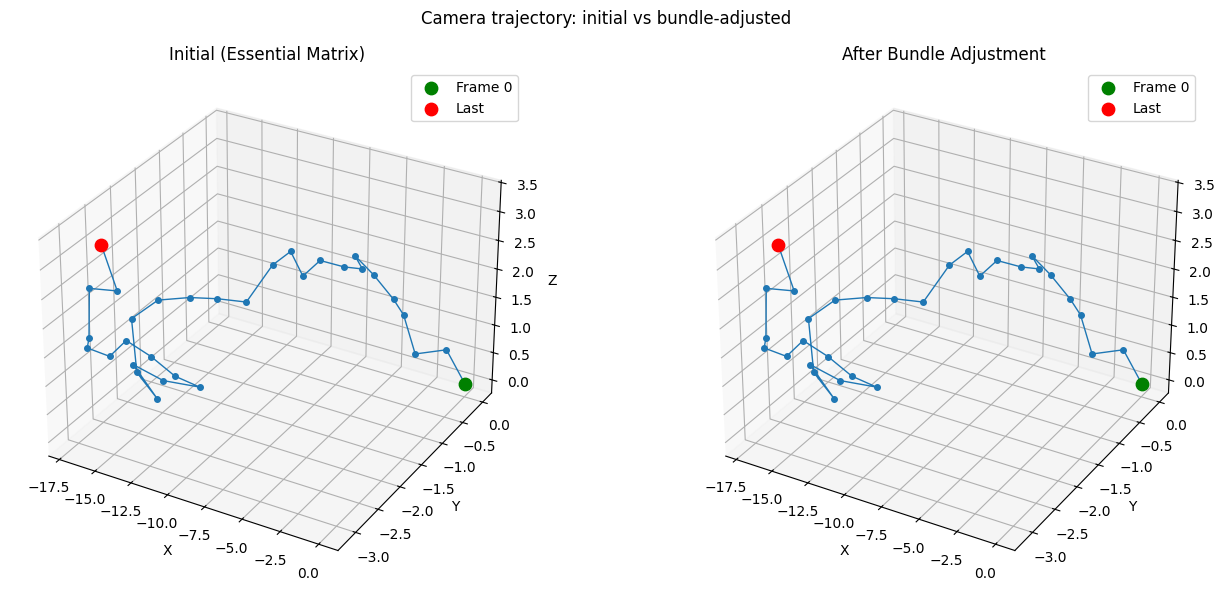

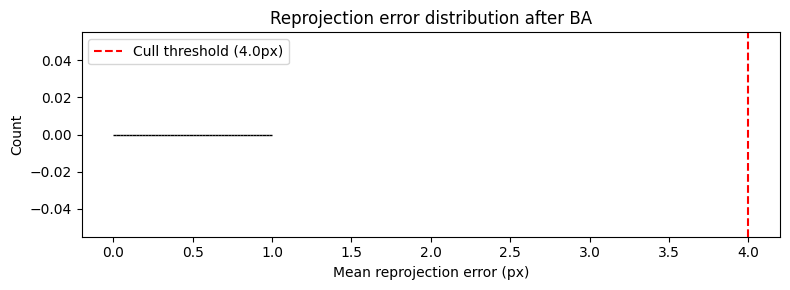

In [12]:
reproj_errors = []
for pt_idx, obs in enumerate(track_obs_ba):
    errs = []
    for (cam_idx, u_obs, v_obs, _) in obs:
        u_p, v_p = project(rvecs_ba[cam_idx], tvecs_ba[cam_idx], pts3d_ba[pt_idx], K)
        errs.append(np.sqrt((u_p - u_obs)**2 + (v_p - v_obs)**2))
    reproj_errors.append(np.mean(errs))

reproj_errors = np.array(reproj_errors)
inlier_mask   = reproj_errors < BA_REPROJ_THRESH
pts3d_inlier  = pts3d_ba[inlier_mask]
print(f"After reprojection cull (thresh={BA_REPROJ_THRESH}px): "
      f"{inlier_mask.sum():,}/{len(inlier_mask):,} points remain "
      f"(mean err={reproj_errors[inlier_mask].mean():.2f}px)")

R_all = R_all_ba
t_all = t_all_ba

def cam_centres(R_arr, t_arr):
    return np.array([-R_arr[i].T @ t_arr[i] for i in range(len(R_arr))])

c_init = cam_centres(R_all_init, t_all_init)
c_ba   = cam_centres(R_all_ba, t_all_ba)

fig = plt.figure(figsize=(14, 6))
for ax_idx, (centres, title) in enumerate([(c_init, "Initial (Essential Matrix)"),
                                            (c_ba,   "After Bundle Adjustment")]):
    ax = fig.add_subplot(1, 2, ax_idx + 1, projection="3d")
    ax.plot(*centres.T, "o-", markersize=4, linewidth=1)
    ax.scatter(*centres[0], s=80, c="green", zorder=5, label="Frame 0")
    ax.scatter(*centres[-1], s=80, c="red",  zorder=5, label="Last")
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title(title); ax.legend()

plt.suptitle("Camera trajectory: initial vs bundle-adjusted")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 3))
plt.hist(reproj_errors, bins=50, color="steelblue", edgecolor="k")
plt.axvline(BA_REPROJ_THRESH, color="red", linestyle="--", label=f"Cull threshold ({BA_REPROJ_THRESH}px)")
plt.xlabel("Mean reprojection error (px)"); plt.ylabel("Count")
plt.title("Reprojection error distribution after BA")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
def load_image_cv(path):
    """Load + undistort + preprocess a TIFF image."""
    return load_cv(path)

def silhouette_otsu(img, invert=False):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return cv2.bitwise_not(mask) if invert else mask

def silhouette_threshold(img, thresh=15, invert=False):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, mask = cv2.threshold(blur, thresh, 255, cv2.THRESH_BINARY)
    return cv2.bitwise_not(mask) if invert else mask

def silhouette_hsv(img, h_lo=0, h_hi=180, s_lo=30, v_lo=30):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    return cv2.inRange(hsv,
                       np.array([h_lo, s_lo, v_lo]),
                       np.array([h_hi, 255, 255]))

def clean_mask(mask, morph_k=5):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_k, morph_k))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    mask = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))
    return mask

print("Silhouette functions defined.")

Silhouette functions defined.


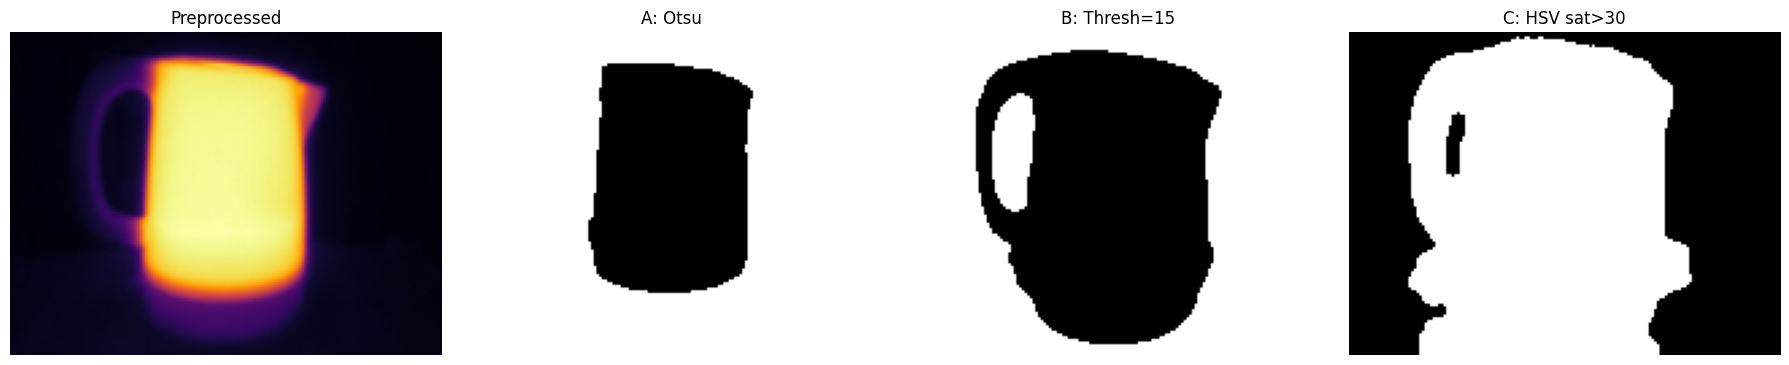

In [ ]:
SAMPLE_IDX = 0
img_sample = load_image_cv(image_paths[SAMPLE_IDX])

masks = {
    "A: Otsu"       : clean_mask(silhouette_otsu(img_sample, invert=True)),
    "B: Thresh=15"  : clean_mask(silhouette_threshold(img_sample, thresh=15, invert=True)),
    "C: HSV sat>30" : clean_mask(silhouette_hsv(img_sample)),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(cv2.cvtColor(img_sample, cv2.COLOR_BGR2RGB))
axes[0].set_title("Preprocessed")
for ax, (title, m) in zip(axes[1:], masks.items()):
    ax.imshow(m, cmap="gray"); ax.set_title(title)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [ ]:
@interact(
    thresh=IntSlider(min=10, max=250, step=5, value=80, description="Threshold"),
    morph_k=IntSlider(min=1, max=21, step=2, value=5, description="Morph kernel"),
    invert=True,
    view_idx=IntSlider(min=0, max=num_views-1, step=1, value=0, description="View")
)
def preview_thresh(thresh, morph_k, invert, view_idx):
    img  = load_image_cv(image_paths[view_idx])
    mask = clean_mask(silhouette_threshold(img, thresh=thresh, invert=invert), morph_k)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Preprocessed")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(f"thresh={thresh}, morph={morph_k}, inv={invert}")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=80, description='Threshold', max=250, min=10, step=5), IntSlider(value=5…

In [ ]:
SILHOUETTE_METHOD = "threshold"
THRESH_VALUE  = 15
THRESH_INVERT = False
MORPH_K       = 5

def get_silhouette(img):
    if SILHOUETTE_METHOD == "otsu":
        m = silhouette_otsu(img, invert=THRESH_INVERT)
    elif SILHOUETTE_METHOD == "threshold":
        m = silhouette_threshold(img, thresh=THRESH_VALUE, invert=THRESH_INVERT)
    elif SILHOUETTE_METHOD == "hsv":
        m = silhouette_hsv(img)
    else:
        raise ValueError(f"Unknown method: {SILHOUETTE_METHOD}")
    return clean_mask(m, morph_k=MORPH_K)

print(f"Using silhouette method: {SILHOUETTE_METHOD}")

Using silhouette method: threshold


In [ ]:
N  = VOXEL_GRID_SIZE
xs = np.linspace(-VOXEL_EXTENT_XY, VOXEL_EXTENT_XY, N)
ys = np.linspace(-VOXEL_EXTENT_XY, VOXEL_EXTENT_XY, N)
zs = np.linspace(VOXEL_Z_OFFSET,   VOXEL_Z_OFFSET + VOXEL_EXTENT_Z, N)

Xg, Yg, Zg = np.meshgrid(xs, ys, zs, indexing="ij")
ones        = np.ones_like(Xg)
pts_world   = np.stack([Xg.ravel(), Yg.ravel(), Zg.ravel(), ones.ravel()], axis=0)
occupied    = np.ones(N * N * N, dtype=bool)
print(f"Voxel grid: {N}³ = {N**3:,} voxels")

img0 = load_image_cv(image_paths[0])
img_h, img_w = img0.shape[:2]

for i in range(num_views):
    R = R_all[i]; t = t_all[i]

    p_cam    = R @ pts_world[:3] + t[:, None]
    in_front = p_cam[2] > 0

    u  = K[0, 0] * p_cam[0] / p_cam[2] + K[0, 2]
    v  = K[1, 1] * p_cam[1] / p_cam[2] + K[1, 2]
    ui = np.round(u).astype(int)
    vi = np.round(v).astype(int)

    in_frame = (ui >= 0) & (ui < img_w) & (vi >= 0) & (vi < img_h)
    valid    = in_front & in_frame

    img  = load_image_cv(image_paths[i])
    mask = get_silhouette(img)

    sil_vals = np.zeros(N * N * N, dtype=np.uint8)
    sil_vals[valid] = mask[vi[valid], ui[valid]]

    occupied[valid & (sil_vals == 0)] = False

    pct = occupied.sum() / N**3 * 100
    print(f"  View {i+1:2d}/{num_views}  remaining: {occupied.sum():7,}  ({pct:.1f}%)")

occ_volume = occupied.reshape(N, N, N)
print(f"\nCarving done. Final: {occupied.sum():,} voxels ({occupied.mean()*100:.1f}%)")

Voxel grid: 96³ = 884,736 voxels
  View  1/32  remaining: 758,685  (85.8%)
  View  2/32  remaining: 758,685  (85.8%)
  View  3/32  remaining: 758,685  (85.8%)
  View  4/32  remaining: 758,685  (85.8%)
  View  5/32  remaining: 758,685  (85.8%)


/tmp/ipykernel_1176/3937689702.py:21: RuntimeWarning: divide by zero encountered in divide
  u  = K[0, 0] * p_cam[0] / p_cam[2] + K[0, 2]
/tmp/ipykernel_1176/3937689702.py:22: RuntimeWarning: divide by zero encountered in divide
  v  = K[1, 1] * p_cam[1] / p_cam[2] + K[1, 2]
/tmp/ipykernel_1176/3937689702.py:23: RuntimeWarning: invalid value encountered in cast
  ui = np.round(u).astype(int)
/tmp/ipykernel_1176/3937689702.py:24: RuntimeWarning: invalid value encountered in cast
  vi = np.round(v).astype(int)


  View  6/32  remaining: 758,685  (85.8%)
  View  7/32  remaining: 758,685  (85.8%)
  View  8/32  remaining: 758,685  (85.8%)
  View  9/32  remaining: 758,685  (85.8%)
  View 10/32  remaining: 758,685  (85.8%)
  View 11/32  remaining: 758,685  (85.8%)
  View 12/32  remaining: 758,685  (85.8%)
  View 13/32  remaining: 758,685  (85.8%)
  View 14/32  remaining: 758,685  (85.8%)
  View 15/32  remaining: 758,685  (85.8%)
  View 16/32  remaining: 758,685  (85.8%)
  View 17/32  remaining: 758,685  (85.8%)
  View 18/32  remaining: 758,685  (85.8%)
  View 19/32  remaining: 758,685  (85.8%)
  View 20/32  remaining: 758,685  (85.8%)
  View 21/32  remaining: 758,685  (85.8%)
  View 22/32  remaining: 758,685  (85.8%)
  View 23/32  remaining: 758,685  (85.8%)
  View 24/32  remaining: 758,685  (85.8%)
  View 25/32  remaining: 758,685  (85.8%)
  View 26/32  remaining: 758,685  (85.8%)
  View 27/32  remaining: 758,685  (85.8%)
  View 28/32  remaining: 758,685  (85.8%)
  View 29/32  remaining: 758,685  

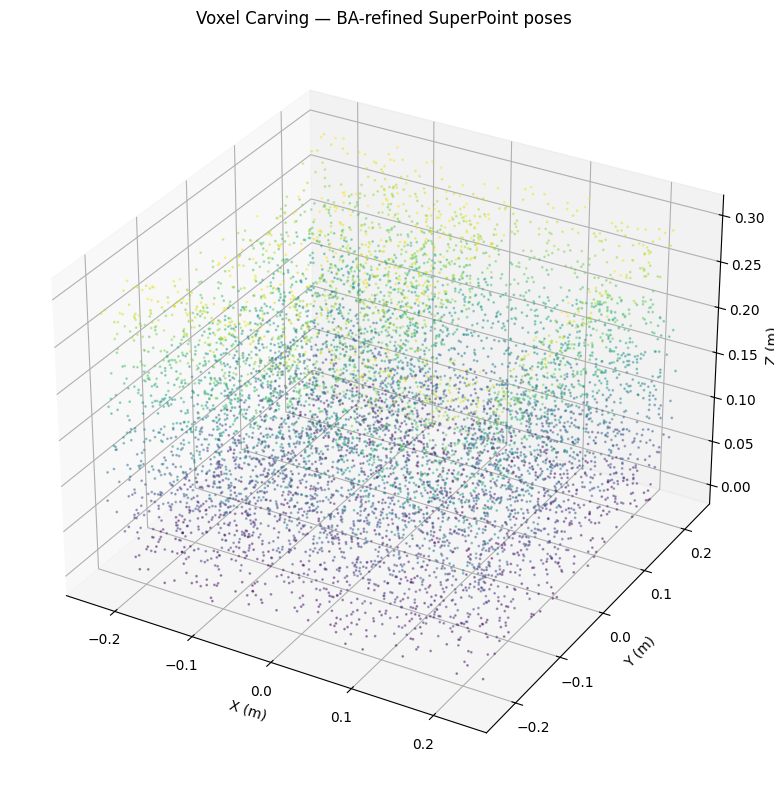

In [ ]:
MAX_POINTS = 8000
occ_idx = np.argwhere(occ_volume)
if len(occ_idx) > MAX_POINTS:
    sel = np.random.choice(len(occ_idx), MAX_POINTS, replace=False)
    occ_idx = occ_idx[sel]

ox = xs[occ_idx[:, 0]]; oy = ys[occ_idx[:, 1]]; oz = zs[occ_idx[:, 2]]

fig = plt.figure(figsize=(8, 8))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(ox, oy, oz, s=1, c=oz, cmap="viridis", alpha=0.4)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
ax.set_title("Voxel Carving — BA-refined SuperPoint poses")
plt.tight_layout(); plt.show()

In [ ]:
@interact(
    z_slice=IntSlider(min=0, max=N-1, step=1, value=N//2, description="Z slice"),
    y_slice=IntSlider(min=0, max=N-1, step=1, value=N//2, description="Y slice"),
    x_slice=IntSlider(min=0, max=N-1, step=1, value=N//2, description="X slice"),
)
def show_slices(z_slice, y_slice, x_slice):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(occ_volume[:, :, z_slice].T, origin="lower", cmap="gray",
                   extent=[xs[0], xs[-1], ys[0], ys[-1]])
    axes[0].set_title(f"XY  z={zs[z_slice]:.3f} m")
    axes[1].imshow(occ_volume[:, y_slice, :].T, origin="lower", cmap="gray",
                   extent=[xs[0], xs[-1], zs[0], zs[-1]])
    axes[1].set_title(f"XZ  y={ys[y_slice]:.3f} m")
    axes[2].imshow(occ_volume[x_slice, :, :].T, origin="lower", cmap="gray",
                   extent=[ys[0], ys[-1], zs[0], zs[-1]])
    axes[2].set_title(f"YZ  x={xs[x_slice]:.3f} m")
    for ax in axes:
        ax.set_xlabel("m"); ax.set_ylabel("m")
    plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=48, description='Z slice', max=95), IntSlider(value=48, description='Y s…

In [ ]:
# Use preprocessed images for photometric consistency
imgs_gray = []
for path in image_paths:
    img  = load_cv(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    imgs_gray.append(gray)

H, W = imgs_gray[0].shape
print(f"Images: {H}×{W}  |  {num_views} views loaded (preprocessed)")

Images: 120×160  |  32 views loaded (preprocessed)


In [ ]:
from scipy.ndimage import gaussian_filter

def compute_depth_map(ref_idx, imgs, K, R_all, t_all,
                      D_MIN=0.30, D_MAX=0.65, D_STEPS=64,
                      cost_thresh=0.15, lambda_s=0.15):
    depths = np.linspace(D_MIN, D_MAX, D_STEPS)
    DSI    = np.full((H, W, D_STEPS), np.inf, dtype=np.float32)

    R_R, t_R = R_all[ref_idx], t_all[ref_idx]
    u_grid, v_grid = np.meshgrid(np.arange(W), np.arange(H))
    ray_x = (u_grid - K[0, 2]) / K[0, 0]
    ray_y = (v_grid - K[1, 2]) / K[1, 1]

    for di, d in enumerate(depths):
        p_cam_R = np.stack([ray_x * d, ray_y * d, np.full((H, W), d)], axis=-1)
        p_world = (R_R.T @ (p_cam_R.reshape(-1, 3).T - t_R[:, None])).T

        cost_accum = np.zeros((H, W), dtype=np.float32)
        count      = np.zeros((H, W), dtype=np.float32)

        for k in range(len(imgs)):
            if k == ref_idx:
                continue
            p_cam_k = R_all[k] @ p_world.T + t_all[k][:, None]
            zk      = p_cam_k[2].reshape(H, W)
            u_k = (K[0, 0] * p_cam_k[0] / p_cam_k[2] + K[0, 2]).reshape(H, W).astype(np.float32)
            v_k = (K[1, 1] * p_cam_k[1] / p_cam_k[2] + K[1, 2]).reshape(H, W).astype(np.float32)
            sampled = cv2.remap(imgs[k], u_k, v_k,
                                cv2.INTER_LINEAR, cv2.BORDER_CONSTANT, borderValue=-1)
            in_bounds = (u_k >= 0) & (u_k < W-1) & (v_k >= 0) & (v_k < H-1) & (zk > 0)
            err = np.abs(imgs[ref_idx] - sampled)
            cost_accum[in_bounds] += err[in_bounds]
            count[in_bounds]      += 1

        valid = count > 3
        DSI[:, :, di][valid]  = cost_accum[valid] / count[valid]
        DSI[:, :, di][~valid] = np.inf

    gx  = cv2.Sobel(imgs[ref_idx], cv2.CV_32F, 1, 0)
    gy  = cv2.Sobel(imgs[ref_idx], cv2.CV_32F, 0, 1)
    rho = np.exp(-(gx**2 + gy**2) / 0.05)
    for di in range(D_STEPS):
        s = gaussian_filter(DSI[:, :, di], sigma=1.5)
        DSI[:, :, di] += lambda_s * rho * s

    best_d_idx = np.argmin(DSI, axis=2)
    depth_map  = depths[best_d_idx].astype(np.float32)
    min_cost   = DSI[np.arange(H)[:, None], np.arange(W)[None, :], best_d_idx]
    depth_map[min_cost > cost_thresh] = 0
    return depth_map


print("Computing depth maps for all views (may take a few minutes)…")
all_depth_maps = []
for ref in range(num_views):
    print(f"  Depth map {ref+1}/{num_views}", end="\r")
    dm = compute_depth_map(ref, imgs_gray, K, R_all, t_all)
    all_depth_maps.append(dm)
print("\nDone.")

Computing depth maps for all views (may take a few minutes)…


/tmp/ipykernel_1176/3406012985.py:44: RuntimeWarning: invalid value encountered in multiply
  DSI[:, :, di] += lambda_s * rho * s



Done.


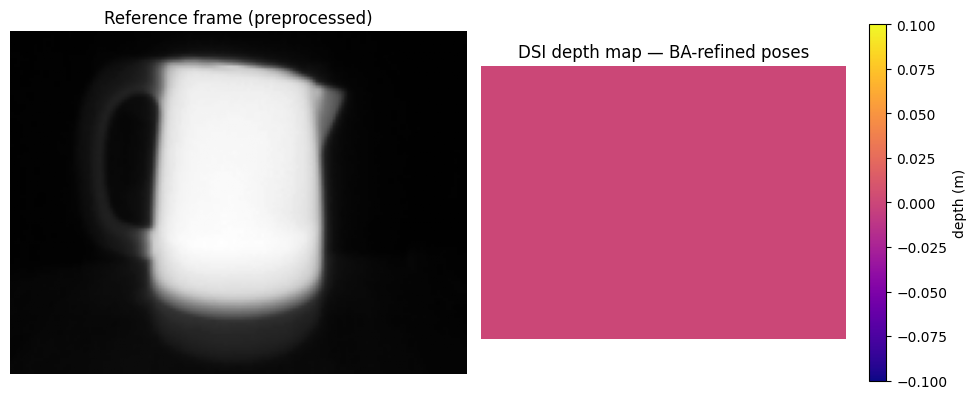

In [ ]:
REF = 0
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(imgs_gray[REF], cmap="gray")
plt.title("Reference frame (preprocessed)")
plt.axis("off")
plt.subplot(122)
plt.imshow(all_depth_maps[REF], cmap="plasma")
plt.colorbar(label="depth (m)")
plt.title("DSI depth map — BA-refined poses")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def depth_to_pointcloud(depth_map, ref_idx, K, R_all, t_all):
    R_R, t_R = R_all[ref_idx], t_all[ref_idx]
    u_grid, v_grid = np.meshgrid(np.arange(W), np.arange(H))
    valid = depth_map > 0
    d_v   = depth_map[valid]
    x_c   = (u_grid[valid] - K[0, 2]) / K[0, 0] * d_v
    y_c   = (v_grid[valid] - K[1, 2]) / K[1, 1] * d_v
    p_cam = np.stack([x_c, y_c, d_v], axis=0)
    return (R_R.T @ (p_cam - t_R[:, None])).T

all_points   = [depth_to_pointcloud(all_depth_maps[r], r, K, R_all, t_all)
                for r in range(num_views)]
points_fused = np.concatenate(all_points, axis=0)
print(f"Total points before filtering: {len(points_fused):,}")

mask = (
    (np.abs(points_fused[:, 0]) < 0.20) &
    (np.abs(points_fused[:, 1]) < 0.20) &
    (points_fused[:, 2] > 0.0) &
    (points_fused[:, 2] < 0.45)
)
points_clean = points_fused[mask]
print(f"After bbox filter: {len(points_clean):,}")

from sklearn.neighbors import NearestNeighbors
nbrs   = NearestNeighbors(n_neighbors=10).fit(points_clean)
dists, _ = nbrs.kneighbors(points_clean)
mean_d = dists[:, 1:].mean(axis=1)
points_clean = points_clean[mean_d < mean_d.mean() + 2 * mean_d.std()]
print(f"After outlier removal: {len(points_clean):,}")

fig = plt.figure(figsize=(8, 8))
ax  = fig.add_subplot(111, projection="3d")
idx = np.random.choice(len(points_clean), min(10000, len(points_clean)), replace=False)
ax.scatter(*points_clean[idx].T, s=1, c=points_clean[idx, 2], cmap="viridis", alpha=0.5)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Fused DSI point cloud — BA-refined poses")
plt.tight_layout(); plt.show()

Total points before filtering: 18,434
After bbox filter: 0


ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by NearestNeighbors.

## 12. Export

In [ ]:
np.save("voxel_grid_superpoint_ba.npy", occ_volume)
print("Saved voxel_grid_superpoint_ba.npy  shape:", occ_volume.shape)

def save_ply(filename, points):
    with open(filename, "w") as f:
        f.write(f"ply\nformat ascii 1.0\nelement vertex {len(points)}\n"
                "property float x\nproperty float y\nproperty float z\nend_header\n")
        for p in points:
            f.write(f"{p[0]:.6f} {p[1]:.6f} {p[2]:.6f}\n")
    print(f"Saved {len(points):,} points → {filename}")

occ_idx_full  = np.argwhere(occ_volume)
pts_world_occ = np.column_stack([xs[occ_idx_full[:, 0]],
                                 ys[occ_idx_full[:, 1]],
                                 zs[occ_idx_full[:, 2]]])
save_ply("voxel_cloud_superpoint_ba.ply", pts_world_occ)
save_ply("dsi_pointcloud_superpoint_ba.ply", points_clean)

# Save BA-refined poses
poses_out = {
    "R_world_to_cam": R_all,
    "t_world_to_cam": t_all,
    "num_views":       num_views,
    "method":          "superpoint+lightglue+essential+BA+thermal_preproc",
    "metric_scale":    metric_scale,
}
with open("camera_poses_superpoint_ba.pkl", "wb") as f:
    pickle.dump(poses_out, f)
print("Saved camera_poses_superpoint_ba.pkl")